# Train and Compare Models
Train baseline Logistic Regression and Random Forest, then compare metrics and plots.

In [4]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from joblib import dump

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    RocCurveDisplay,
    PrecisionRecallDisplay,
 )

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'scripts').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from scripts.models import build_logistic_regression, build_random_forest

DATA_DIR = PROJECT_ROOT / 'data' / 'processed' / 'model_ready'
MODELS_DIR = PROJECT_ROOT / 'models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)
TARGET = 'Diabetes_binary'

sns.set_theme(style='whitegrid')

In [5]:
# Load preprocessed data
train_lr = pd.read_csv(DATA_DIR / 'train_lr_scaled.csv')
test_lr = pd.read_csv(DATA_DIR / 'test_lr_scaled.csv')
train_rf = pd.read_csv(DATA_DIR / 'train_rf_ready.csv')
test_rf = pd.read_csv(DATA_DIR / 'test_rf_ready.csv')

print('LR train/test:', train_lr.shape, test_lr.shape)
print('RF train/test:', train_rf.shape, test_rf.shape)

LR train/test: (202944, 13) (50736, 13)
RF train/test: (202944, 22) (50736, 22)


In [6]:
# Split features/targets
X_train_lr = train_lr.drop(columns=[TARGET])
y_train_lr = train_lr[TARGET].astype('int64')
X_test_lr = test_lr.drop(columns=[TARGET])
y_test_lr = test_lr[TARGET].astype('int64')

X_train_rf = train_rf.drop(columns=[TARGET])
y_train_rf = train_rf[TARGET].astype('int64')
X_test_rf = test_rf.drop(columns=[TARGET])
y_test_rf = test_rf[TARGET].astype('int64')

## Train models

In [7]:
# Build and train Logistic Regression
lr_model = build_logistic_regression(random_state=42)
lr_model.fit(X_train_lr, y_train_lr)

# Build and train Random Forest
rf_model = build_random_forest(random_state=42)
rf_model.fit(X_train_rf, y_train_rf)

print('Models trained.')

Models trained.


In [8]:
# Save trained models for reuse in the app
dump(lr_model, MODELS_DIR / 'logistic_regression.joblib')
dump(rf_model, MODELS_DIR / 'random_forest.joblib')

print('Saved:', MODELS_DIR / 'logistic_regression.joblib')
print('Saved:', MODELS_DIR / 'random_forest.joblib')

Saved: d:\Final\Dm_Final\Diabetes-DW-Prediction\models\logistic_regression.joblib
Saved: d:\Final\Dm_Final\Diabetes-DW-Prediction\models\random_forest.joblib


## Evaluate metrics

In [9]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)
    
    metrics = {
        'model': name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_prob),
    }
    return metrics, y_pred, y_prob

lr_metrics, lr_pred, lr_prob = evaluate_model('Logistic Regression', lr_model, X_test_lr, y_test_lr)
rf_metrics, rf_pred, rf_prob = evaluate_model('Random Forest', rf_model, X_test_rf, y_test_rf)

metrics_df = pd.DataFrame([lr_metrics, rf_metrics]).set_index('model')
metrics_df

,accuracy,precision,recall,f1,roc_auc
model,,,,,
Logistic Regression,0.726250,0.306382,0.763333,0.437259,0.815804
Random Forest,0.856749,0.458559,0.155750,0.232524,0.794987


## Confusion matrices

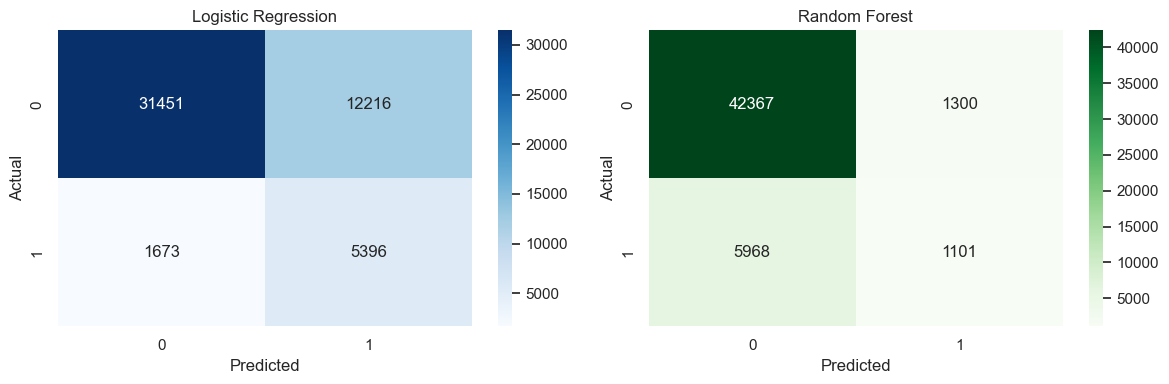

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm_lr = confusion_matrix(y_test_lr, lr_pred)
cm_rf = confusion_matrix(y_test_rf, rf_pred)

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Random Forest')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

## ROC and PR curves

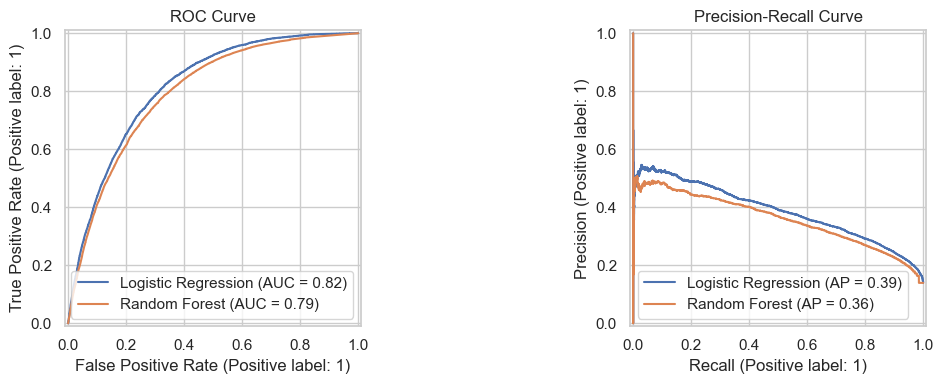

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

RocCurveDisplay.from_predictions(y_test_lr, lr_prob, ax=axes[0], name='Logistic Regression')
RocCurveDisplay.from_predictions(y_test_rf, rf_prob, ax=axes[0], name='Random Forest')
axes[0].set_title('ROC Curve')

PrecisionRecallDisplay.from_predictions(y_test_lr, lr_prob, ax=axes[1], name='Logistic Regression')
PrecisionRecallDisplay.from_predictions(y_test_rf, rf_prob, ax=axes[1], name='Random Forest')
axes[1].set_title('Precision-Recall Curve')

plt.tight_layout()
plt.show()

## Metric comparison chart

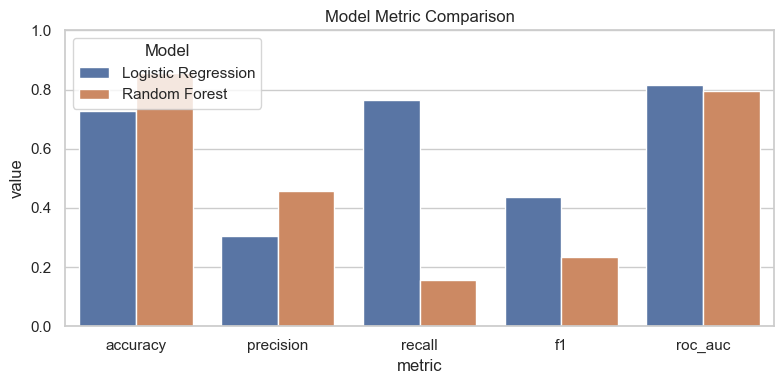

In [12]:
plot_df = metrics_df.reset_index().melt(id_vars='model', var_name='metric', value_name='value')
plt.figure(figsize=(8, 4))
sns.barplot(data=plot_df, x='metric', y='value', hue='model')
plt.ylim(0, 1)
plt.title('Model Metric Comparison')
plt.legend(title='Model')
plt.tight_layout()
plt.show()

## Feature importance (RF)

C:\Users\Tun tun\AppData\Local\Temp\ipykernel_2504\194730775.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rf_importance.head(15).values, y=rf_importance.head(15).index, palette='viridis')


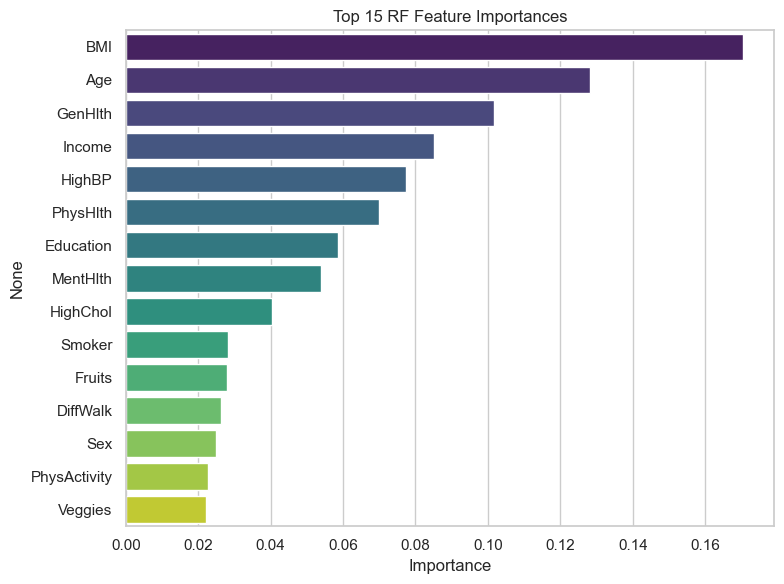

In [13]:
rf_importance = pd.Series(rf_model.feature_importances_, index=X_train_rf.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 6))
sns.barplot(x=rf_importance.head(15).values, y=rf_importance.head(15).index, palette='viridis')
plt.title('Top 15 RF Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()